In [57]:
from sklearn.datasets      import make_multilabel_classification
from sklearn.metrics       import classification_report
from sklearn.metrics       import label_ranking_loss
from sklearn.preprocessing import OneHotEncoder

import matplotlib.pyplot   as plt
from train_eval import eval_model, train_model

import torch
torch.manual_seed(seed = 42)

import torch.nn as nn
from torch.utils.data        import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from tqdm import tqdm
device = torch.device("cpu") #torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Device", device)


Device cpu


In [30]:
X, y = make_multilabel_classification(n_features      = 2,
                                      length          = 10,
                                      n_samples       = 100,
                                      n_classes       = 5,
                                      n_labels        = 2,
                                      allow_unlabeled = False,
                                      random_state    = 42)
print(X.shape)
print(y.shape)
print(y[0])

(100, 2)
(100, 5)
[0 0 1 0 0]


In [56]:
#plt.figure(figsize=(3,3))
#plt.scatter(X[:,0],X[:,1],c = y[:,0])
#plt.show()

In [33]:
X_train, X_test, Y_train, Y_test = train_test_split(X,y, test_size = 0.2,random_state = 42) 

X_train = torch.from_numpy(X_train).type(torch.float32)
Y_train = torch.from_numpy(Y_train).type(torch.float32)

X_test  = torch.from_numpy(X_test) .type(torch.float32)
Y_test  = torch.from_numpy(Y_test) .type(torch.float32)

training_dataset = TensorDataset(X_train,Y_train)
testing_dataset  = TensorDataset(X_test ,Y_test )

train_loader = DataLoader(TensorDataset(X_train,Y_train) , batch_size = X_train.shape[0], shuffle = False)
test_loader  = DataLoader(TensorDataset(X_test ,Y_test ) , batch_size = X_test.shape[0] , shuffle = False)

In [59]:
def generate_model():
    model = nn.Sequential(
        nn.Linear(2, 100),
        nn.Dropout(0.2),
        nn.ReLU(),
        nn.Linear(100, 100),
        nn.Dropout(0.2),
        nn.ReLU(),
        nn.Linear(100, 5),
        nn.Sigmoid()
    )
    return model
model = generate_model()

loss_module = torch.nn.BCELoss()
optimizer   = torch.optim.Adam(model.parameters(), lr=0.01, betas = (0.9,0.99)) #(0.1,0.3)

In [60]:
eval_model(model        = model,
           device       = device,
           data_loader  = test_loader,
           target_names = [f'Label {i}' for i in range(y.shape[1])])

              precision    recall  f1-score   support

     Label 0       0.00      0.00      0.00         7
     Label 1       0.00      0.00      0.00        14
     Label 2       1.00      0.36      0.53        11
     Label 3       0.53      0.91      0.67        11
     Label 4       0.20      1.00      0.33         4

   micro avg       0.42      0.38      0.40        47
   macro avg       0.35      0.45      0.31        47
weighted avg       0.37      0.38      0.31        47
 samples avg       0.40      0.37      0.36        47



In [61]:
hist = train_model(model       = model,
                   device      = device,
                   optimizer   = optimizer,
                   data_loader = train_loader,
                   loss_module = loss_module,
                   num_epochs  = 200)

100%|██████████| 200/200 [00:00<00:00, 455.13it/s]


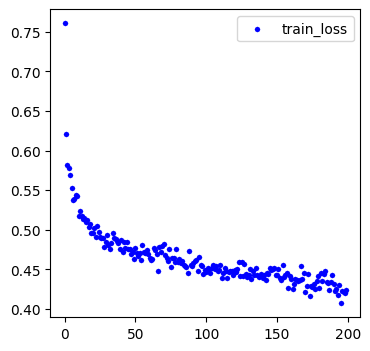

In [62]:
plt.figure(figsize=(4,4))
plt.scatter(y = hist,
            x = [_ for _ in range(len(hist))],
            alpha = 1, lw = 0.1, c = 'b', s = 14, label = 'train_loss')
plt.legend(); plt.show()

In [63]:
eval_model(model        = model,
           device       = device,
           data_loader  = test_loader,
           target_names = [f'Label {i}' for i in range(y.shape[1])])

              precision    recall  f1-score   support

     Label 0       0.33      0.14      0.20         7
     Label 1       0.83      0.71      0.77        14
     Label 2       0.67      0.91      0.77        11
     Label 3       0.86      0.55      0.67        11
     Label 4       0.00      0.00      0.00         4

   micro avg       0.71      0.57      0.64        47
   macro avg       0.54      0.46      0.48        47
weighted avg       0.65      0.57      0.59        47
 samples avg       0.69      0.66      0.64        47



---

In [89]:
#clients = [generate_model() for _ in range(3)]
n_clients = 3
samples = len(training_dataset)
splits = list( torch.linspace(0,100, steps = n_clients + 1).long() )
for idx in range(0,len(splits) - 1):
    print(splits[idx:idx + 2])

[tensor(0), tensor(33)]
[tensor(33), tensor(66)]
[tensor(66), tensor(100)]
